In [35]:
 #This example uses Python 2.7 and the python-request library.

from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
#url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'5000',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': 'b54bcf4d-1bca-4e8e-9a24-22ff2c3d462c',
    #8c2e5a807cbc494e8b83ac8d6db0a271
    #b54bcf4d-1bca-4e8e-9a24-22ff2c3d462c
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

{'status': {'timestamp': '2026-01-21T05:38:20.864Z', 'error_code': 0, 'error_message': None, 'elapsed': 1, 'credit_count': 1, 'notice': None}, 'data': [{'id': 1352, 'name': 'c8naesoo9qi', 'symbol': '6m2r2nqokts', 'slug': 'v86ks26v6cg', 'cmc_rank': 4457, 'num_market_pairs': 9417, 'circulating_supply': 2249, 'total_supply': 9050, 'max_supply': 3089, 'infinite_supply': None, 'last_updated': '2026-01-21T05:38:20.863Z', 'date_added': '2026-01-21T05:38:20.863Z', 'tags': ['yppfsztw7g', '73amhboii3m', 'jnxhgotufm', 'x2dlo902kpq', 'xfuvf8dwiap', 'lcrd8crhm7h', '0orehrbgiami', 'hdyajyhzjke', 'vs8ohqewxu', '3h0xnkoijsa'], 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 0.38467974625689516, 'quote': {'USD': {'price': 0.3844033594367422, 'volume_24h': 900, 'volume_change_24h': 0.5930926663365839, 'percent_change_1h': 0.8741205181481397, 'percent_change_24h': 0.6446789415117464, 'percent_change_7d': 0.14965383545582656, 'market_cap':

In [36]:
type(data)

dict

In [20]:
data.keys()
print(data['status'])


{'timestamp': '2026-01-21T05:30:27.556Z', 'error_code': 0, 'error_message': None, 'elapsed': 1, 'credit_count': 1, 'notice': None}


In [24]:
import pandas as pd


#This allows you to see all the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [25]:
#This normalizes the data and makes it all pretty in a dataframe

df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,cmc_rank,num_market_pairs,circulating_supply,total_supply,max_supply,infinite_supply,last_updated,date_added,tags,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.last_updated,timestamp
0,4033,vigouq3qzp9,tiyaeyqihq,y7po6k0gclo,6095,1306,7645,8697,2191,None,2026-01-21T05:30:27.556Z,2026-01-21T05:30:27.556Z,"[rvztldkboa, e7vn5dn4g4a, 0xojd2fbdlzc, 2n4i4v...",None,None,None,0.625581,0.238313,1426,0.977157,0.588322,0.345904,0.791041,0.486637,7598,0.751010,2026-01-21T05:30:27.556Z,2026-01-21 07:31:03.471514
1,3029,8rqf9kzeacx,r6uampkcl2j,y6mm94u63tp,4622,9804,1066,2511,719,None,2026-01-21T05:30:27.556Z,2026-01-21T05:30:27.556Z,"[cargsx5if3, v6k1zqqcgn, x6q8g0jsabs, 9dret1nr...",None,None,None,0.692300,0.600072,1085,0.708487,0.252370,0.979904,0.182803,0.566984,864,0.389970,2026-01-21T05:30:27.556Z,2026-01-21 07:31:03.471514
2,9527,0kw8zr8uml1m,72omflc71qk,q4l26wwswsl,7304,4789,2889,387,9524,None,2026-01-21T05:30:27.556Z,2026-01-21T05:30:27.556Z,"[eyhafag3m6h, 98elut3ceug, 4mnn7ribqk7, wvfik7...",None,None,None,0.040044,0.029390,7701,0.516513,0.310411,0.742674,0.311587,0.154608,7635,0.726652,2026-01-21T05:30:27.556Z,2026-01-21 07:31:03.471514
3,8658,sz4eeptm77m,wkvyfmaoxq,qimhx2y49kr,8628,3230,5421,5134,3897,None,2026-01-21T05:30:27.556Z,2026-01-21T05:30:27.556Z,"[urhiounmtq, 1obk427ezpn, lizj9z3cy1b, yh3xugh...",None,None,None,0.854704,0.967431,9431,0.030654,0.507430,0.041945,0.188291,0.017463,6290,0.242678,2026-01-21T05:30:27.556Z,2026-01-21 07:31:03.471514
4,5275,iyfljjdb0hq,jczawi8pjvc,omksgl3tqsg,9599,5934,6978,8328,8705,None,2026-01-21T05:30:27.556Z,2026-01-21T05:30:27.556Z,"[qtq0rkqmtn, f8tjmwydbw, 6t3du63cmgf, d6rhz6h4...",None,None,None,0.680439,0.147335,5265,0.915054,0.848397,0.128892,0.347719,0.850953,9204,0.985982,2026-01-21T05:30:27.556Z,2026-01-21 07:31:03.471514
5,486,e9mjlufi0a5,2ffxiel9wtq,8wq1o3rzmww,5538,6761,5901,8272,5066,None,2026-01-21T05:30:27.556Z,2026-01-21T05:30:27.556Z,"[toan24kul1, hg1mguagdlr, csv8njssw5, o08ksiu1...",None,None,None,0.746479,0.999941,6438,0.550334,0.566742,0.152193,0.605375,0.863654,2613,0.493334,2026-01-21T05:30:27.556Z,2026-01-21 07:31:03.471514
6,5096,rjmzbwflv68,pmo0a5gt7sf,eqxowncud4i,4617,5133,3321,5376,6746,None,2026-01-21T05:30:27.556Z,2026-01-21T05:30:27.556Z,"[8cmmglcfsf7, s8fbt99uwz9, z3ckoj6j42, ph7pf5z...",None,None,None,0.643007,0.333219,4991,0.593310,0.198574,0.267801,0.477804,0.382899,6379,0.932143,2026-01-21T05:30:27.556Z,2026-01-21 07:31:03.471514
7,1819,mhqgkrbh41a,jq4e94fxta,us8dhq6sa5,3793,1705,7878,7472,6754,None,2026-01-21T05:30:27.556Z,2026-01-21T05:30:27.556Z,"[hpew0f5q3aj, 5yctiypu3r7, 9wzsfwssrbe, e9s9me...",None,None,None,0.200389,0.501469,5783,0.013091,0.864363,0.244758,0.587037,0.311535,1973,0.725406,2026-01-21T05:30:27.556Z,2026-01-21 07:31:03.471514
8,5329,u69mtvruf9,q3oyyh4mbbs,rzxl1zw75mm,2922,3682,1478,4060,9999,None,2026-01-21T05:30:27.556Z,2026-01-21T05:30:27.556Z,"[tmrc65cl8kb, bdk75y5co97, 05510jykjho, omuaiq...",None,None,None,0.978218,0.734438,2966,0.658371,0.692970,0.464495,0.121103,0.102447,5318,0.402470,2026-01-21T05:30:27.556Z,2026-01-21 07:31:03.471514
9,543,irb8d3d8qbc,2mn4v1jxvp,d05woriq5ho,3993,9047,1516,7363,6959,None,2026-01-21T05:30:27.556Z,2026-01-21T05:30:27.556Z,"[i85i89qgrxs, b0bvmi6ochn, 7cp1wri69cj, 9udv27...",None,None,None,0.585420,0.904251,8333,0.023810,0.871625,0.846922,0.722037,0.469119,7567,0.428017,2026-01-21T05:30:27.556Z,2026-01-21 07:31:03.471514


In [45]:
def api_runner():
    global df
    url = 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
 
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
       'X-CMC_PRO_API_KEY': 'b54bcf4d-1bca-4e8e-9a24-22ff2c3d462c',
    }

    session = Session()
    session.headers.update(headers)

    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)


    
    # Use this if you just want to keep it in a dataframe
    df2 = pd.json_normalize(data['data'])
    df2['Timestamp'] = pd.to_datetime('now')
    df = pd.concat([df, df2], ignore_index=True)



    # Use this if you want to create a csv and append data to it
    df = pd.json_normalize(data['data'])
    df['timestamp'] = pd.to_datetime('now')
    df

    if not os.path.isfile(r'C:\Users\Alaa\API.csv'):
        df.to_csv(r'C:\Users\Alaa\API.csv', header='column_names')
    else:
        df.to_csv(r'C:\Users\Alaa\API.csv', mode='a', header=False)
        
    #Then to read in the file: df = pd.read_csv(r'C:\Users\alexf\OneDrive\Documents\Python Scripts\API.csv')

# If that didn't work try using the local host URL as shown in the video

In [ ]:
import os 
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print('API Runner completed')
    sleep(60) #sleep for 1 minute
exit()


while True: 
    try:
        api_runner()
        print(f"Captured at: {pd.to_datetime('now')}")
        sleep(60)
    except KeyboardInterrupt:
        print("Stopped by user")
        break
    except Exception as e:
        print(f"Error occurred: {e}")
        sleep(10) 

In [46]:
df72 = pd.read_csv(r'C:\Users\Alaa\API.csv')
df72

,Unnamed: 0,id,name,symbol,slug,cmc_rank,num_market_pairs,circulating_supply,total_supply,max_supply,infinite_supply,last_updated,date_added,tags,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.last_updated,timestamp
0,0,7224,9710rts7b9j,hz7tk6qloqd,o4r7eg7imeh,1865,6926,4183,6377,895,NaN,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"['t587zdksxra', 'xnzkfh6ng9', 'pzhx0nlbgai', '...",NaN,NaN,NaN,0.795780,0.238096,8070,0.641675,0.048322,0.033548,0.358203,0.628174,4406,0.201881,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
1,1,3599,hkc6h0hwnu5,dkt1cp3mm6t,rah3a9ex8am,1953,6565,323,7104,9197,NaN,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"['lbzjcg38hqe', 'vnmb4ylpzl8', 'kuwreje474', '...",NaN,NaN,NaN,0.576775,0.463513,181,0.548410,0.768435,0.407028,0.843711,0.359486,6078,0.900290,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
2,2,1432,ij3jlfgvtz8,2o5fosboqwr,zn5gaxefak,9052,4512,9701,7467,8220,NaN,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"['aqnt0phwx0w', 'amh9g4k28f5', '8inop3g6je5', ...",NaN,NaN,NaN,0.259797,0.497485,5786,0.848430,0.547886,0.696148,0.307535,0.852521,4642,0.921125,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
3,3,5470,xyn1zm7ahg,idn2je18qn,jb706ixh2pp,6640,9451,6892,2904,7605,NaN,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"['s20rmzz7v4', '28lyfrzs004', 'hb1ugzp1j5m', '...",NaN,NaN,NaN,0.971992,0.127567,5578,0.000707,0.319395,0.419402,0.909394,0.919614,6626,0.490655,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
4,4,3070,j57hk5n5nhi,ct1yjtpvqip,ybyhv1pivq,7888,8076,6811,3837,4892,NaN,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"['v9f90j0tpq', 'mywrx2h5yxl', '6xr1j0a99up', '...",NaN,NaN,NaN,0.692134,0.053472,9318,0.634640,0.894661,0.790330,0.243089,0.055596,9437,0.975177,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
5,5,4902,u2nug63xxjn,27cuq9nim35,yjhxhryzu8i,8446,8609,2338,6555,8692,NaN,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"['atxn0ord3bo', '2mttppwv797', '1gxl1gjt0ui', ...",NaN,NaN,NaN,0.385376,0.564712,3331,0.371602,0.709193,0.907185,0.158497,0.480006,7621,0.746741,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
6,6,9374,564favmd30g,9zzlbcfi6z,bqd5tl4a6o6,2933,1717,1263,5520,2167,NaN,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"['sa6temij0e', '5kku5u10fe6', 'pnhpri9hpb', 'u...",NaN,NaN,NaN,0.210716,0.876417,220,0.430982,0.360245,0.935096,0.616623,0.631573,5535,0.965334,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
7,7,5151,bm1nmxv4c0p,yjmoa0656nr,y9ravvvcsq9,3366,352,8338,1243,3011,NaN,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"['vcbkepv5vxp', '46610jqs9pa', 'kbm0hdn5q5h', ...",NaN,NaN,NaN,0.744503,0.525313,5341,0.375669,0.222233,0.718779,0.725517,0.768318,5547,0.687290,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
8,8,5970,fpcuyp5n98d,94c8oqvxt9n,0vi3vpw9gjxi,7111,2793,7586,4272,9827,NaN,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"['7d401pkri4i', 'bu05tossnxw', 'f4r53aoeyc4', ...",NaN,NaN,NaN,0.401014,0.350102,1600,0.360702,0.135378,0.056555,0.344986,0.759133,9116,0.212433,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
9,9,9733,lbu5nocr7c,89kgtvz6nit,n3s1n49nhcf,6028,6779,6615,3716,5217,NaN,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"['e8zslwd6zda', '8qmzw2brzcm', 'l2gz1gshczk', ...",NaN,NaN,NaN,0.301352,0.446425,3842,0.180671,0.903686,0.467275,0.267592,0.832935,881,0.418683,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057


In [49]:
# One thing I noticed was the scientific notation. I like it, but I want to be able to see the numbers in this case

pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [50]:
df

,id,name,symbol,slug,cmc_rank,num_market_pairs,circulating_supply,total_supply,max_supply,infinite_supply,last_updated,date_added,tags,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.last_updated,timestamp
0,7224,9710rts7b9j,hz7tk6qloqd,o4r7eg7imeh,1865,6926,4183,6377,895,None,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"[t587zdksxra, xnzkfh6ng9, pzhx0nlbgai, mwmrs3g...",None,None,None,0.79578,0.23810,8070,0.64168,0.04832,0.03355,0.35820,0.62817,4406,0.20188,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
1,3599,hkc6h0hwnu5,dkt1cp3mm6t,rah3a9ex8am,1953,6565,323,7104,9197,None,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"[lbzjcg38hqe, vnmb4ylpzl8, kuwreje474, vuukp87...",None,None,None,0.57677,0.46351,181,0.54841,0.76843,0.40703,0.84371,0.35949,6078,0.90029,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
2,1432,ij3jlfgvtz8,2o5fosboqwr,zn5gaxefak,9052,4512,9701,7467,8220,None,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"[aqnt0phwx0w, amh9g4k28f5, 8inop3g6je5, y426e8...",None,None,None,0.25980,0.49748,5786,0.84843,0.54789,0.69615,0.30754,0.85252,4642,0.92112,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
3,5470,xyn1zm7ahg,idn2je18qn,jb706ixh2pp,6640,9451,6892,2904,7605,None,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"[s20rmzz7v4, 28lyfrzs004, hb1ugzp1j5m, 8y86gtx...",None,None,None,0.97199,0.12757,5578,0.00071,0.31940,0.41940,0.90939,0.91961,6626,0.49065,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
4,3070,j57hk5n5nhi,ct1yjtpvqip,ybyhv1pivq,7888,8076,6811,3837,4892,None,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"[v9f90j0tpq, mywrx2h5yxl, 6xr1j0a99up, sa45ogm...",None,None,None,0.69213,0.05347,9318,0.63464,0.89466,0.79033,0.24309,0.05560,9437,0.97518,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
5,4902,u2nug63xxjn,27cuq9nim35,yjhxhryzu8i,8446,8609,2338,6555,8692,None,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"[atxn0ord3bo, 2mttppwv797, 1gxl1gjt0ui, 7rcyzi...",None,None,None,0.38538,0.56471,3331,0.37160,0.70919,0.90718,0.15850,0.48001,7621,0.74674,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
6,9374,564favmd30g,9zzlbcfi6z,bqd5tl4a6o6,2933,1717,1263,5520,2167,None,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"[sa6temij0e, 5kku5u10fe6, pnhpri9hpb, uhstxza5...",None,None,None,0.21072,0.87642,220,0.43098,0.36025,0.93510,0.61662,0.63157,5535,0.96533,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
7,5151,bm1nmxv4c0p,yjmoa0656nr,y9ravvvcsq9,3366,352,8338,1243,3011,None,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"[vcbkepv5vxp, 46610jqs9pa, kbm0hdn5q5h, 8qf5xs...",None,None,None,0.74450,0.52531,5341,0.37567,0.22223,0.71878,0.72552,0.76832,5547,0.68729,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
8,5970,fpcuyp5n98d,94c8oqvxt9n,0vi3vpw9gjxi,7111,2793,7586,4272,9827,None,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"[7d401pkri4i, bu05tossnxw, f4r53aoeyc4, hut8o1...",None,None,None,0.40101,0.35010,1600,0.36070,0.13538,0.05656,0.34499,0.75913,9116,0.21243,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057
9,9733,lbu5nocr7c,89kgtvz6nit,n3s1n49nhcf,6028,6779,6615,3716,5217,None,2026-01-21T05:56:34.539Z,2026-01-21T05:56:34.539Z,"[e8zslwd6zda, 8qmzw2brzcm, l2gz1gshczk, 00q0e1...",None,None,None,0.30135,0.44642,3842,0.18067,0.90369,0.46727,0.26759,0.83293,881,0.41868,2026-01-21T05:56:34.539Z,2026-01-21 07:56:35.599057


In [52]:
df.count()

id                                    10
name                                  10
symbol                                10
slug                                  10
cmc_rank                              10
num_market_pairs                      10
circulating_supply                    10
total_supply                          10
max_supply                            10
infinite_supply                        0
last_updated                          10
date_added                            10
tags                                  10
platform                               0
self_reported_circulating_supply       0
self_reported_market_cap               0
minted_market_cap                     10
quote.USD.price                       10
quote.USD.volume_24h                  10
quote.USD.volume_change_24h           10
quote.USD.percent_change_1h           10
quote.USD.percent_change_24h          10
quote.USD.percent_change_7d           10
quote.USD.market_cap                  10
quote.USD.market

In [65]:
df3 = (
    df
    .groupby('name', sort=False)[
        [
            'quote.USD.percent_change_1h',
            'quote.USD.percent_change_24h',
            'quote.USD.percent_change_7d'
        ]
    ]
    .mean()
)

df3


,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d
name,,,
9710rts7b9j,0.04832,0.03355,0.35820
hkc6h0hwnu5,0.76843,0.40703,0.84371
ij3jlfgvtz8,0.54789,0.69615,0.30754
xyn1zm7ahg,0.31940,0.41940,0.90939
j57hk5n5nhi,0.89466,0.79033,0.24309
u2nug63xxjn,0.70919,0.90718,0.15850
564favmd30g,0.36025,0.93510,0.61662
bm1nmxv4c0p,0.22223,0.71878,0.72552
fpcuyp5n98d,0.13538,0.05656,0.34499


In [66]:
df4 = df3.stack()
df4

name                                     
9710rts7b9j  quote.USD.percent_change_1h    0.04832
             quote.USD.percent_change_24h   0.03355
             quote.USD.percent_change_7d    0.35820
hkc6h0hwnu5  quote.USD.percent_change_1h    0.76843
             quote.USD.percent_change_24h   0.40703
             quote.USD.percent_change_7d    0.84371
ij3jlfgvtz8  quote.USD.percent_change_1h    0.54789
             quote.USD.percent_change_24h   0.69615
             quote.USD.percent_change_7d    0.30754
xyn1zm7ahg   quote.USD.percent_change_1h    0.31940
             quote.USD.percent_change_24h   0.41940
             quote.USD.percent_change_7d    0.90939
j57hk5n5nhi  quote.USD.percent_change_1h    0.89466
             quote.USD.percent_change_24h   0.79033
             quote.USD.percent_change_7d    0.24309
u2nug63xxjn  quote.USD.percent_change_1h    0.70919
             quote.USD.percent_change_24h   0.90718
             quote.USD.percent_change_7d    0.15850
564favmd30g  quote.USD

In [67]:
type(df4)

pandas.core.series.Series

In [68]:
df5 = df4.to_frame(name='values')
df5

values
name                                            
9710rts7b9j quote.USD.percent_change_1h  0.04832
            quote.USD.percent_change_24h 0.03355
            quote.USD.percent_change_7d  0.35820
hkc6h0hwnu5 quote.USD.percent_change_1h  0.76843
            quote.USD.percent_change_24h 0.40703
            quote.USD.percent_change_7d  0.84371
ij3jlfgvtz8 quote.USD.percent_change_1h  0.54789
            quote.USD.percent_change_24h 0.69615
            quote.USD.percent_change_7d  0.30754
xyn1zm7ahg  quote.USD.percent_change_1h  0.31940
            quote.USD.percent_change_24h 0.41940
            quote.USD.percent_change_7d  0.90939
j57hk5n5nhi quote.USD.percent_change_1h  0.89466
            quote.USD.percent_change_24h 0.79033
            quote.USD.percent_change_7d  0.24309
u2nug63xxjn quote.USD.percent_change_1h  0.70919
            quote.USD.percent_change_24h 0.90718
            quote.USD.percent_change_7d  0.15850
564favmd30g quote.USD.percent_change_1h  0.36025
            quote.USD.percent_change_24h 0.93510
            quote.USD.percent_change_7d  0.61662
bm1nmxv4c0p quote.USD.percent_change_1h  0.22223
            quote.USD.percent_change_24h 0.71878
            quote.USD.percent_change_7d  0.72552
fpcuyp5n98d quote.USD.percent_change_1h  0.13538
            quote.USD.percent_change_24h 0.05656
            quote.USD.percent_change_7d  0.34499
lbu5nocr7c  quote.USD.percent_change_1h  0.90369
            quote.USD.percent_change_24h 0.46727
            quote.USD.percent_change_7d  0.26759

In [94]:
df7 = df4.reset_index(name='values')
df7



,name,level_1,values
0,9710rts7b9j,quote.USD.percent_change_1h,0.04832
1,9710rts7b9j,quote.USD.percent_change_24h,0.03355
2,9710rts7b9j,quote.USD.percent_change_7d,0.35820
3,hkc6h0hwnu5,quote.USD.percent_change_1h,0.76843
4,hkc6h0hwnu5,quote.USD.percent_change_24h,0.40703
5,hkc6h0hwnu5,quote.USD.percent_change_7d,0.84371
6,ij3jlfgvtz8,quote.USD.percent_change_1h,0.54789
7,ij3jlfgvtz8,quote.USD.percent_change_24h,0.69615
8,ij3jlfgvtz8,quote.USD.percent_change_7d,0.30754
9,xyn1zm7ahg,quote.USD.percent_change_1h,0.31940


In [102]:
df7 = df4.reset_index(name='values')


In [103]:
df7 = df7.rename(columns={'level_1': 'percent_change'})


In [104]:
mapping = {
    'quote.USD.percent_change_1h': '1h',
    'quote.USD.percent_change_24h': '24h',
    'quote.USD.percent_change_7d': '7d'
}

df7['percent_change'] = df7['percent_change'].replace(mapping)


In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

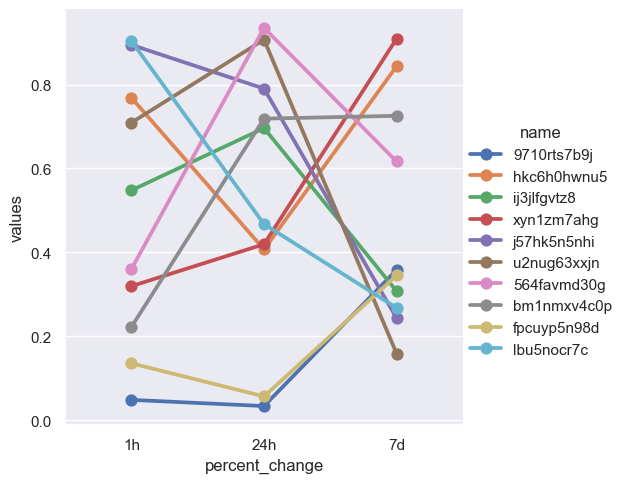

In [105]:
sns.catplot(
    x='percent_change',
    y='values',
    hue='name',
    data=df7,
    kind='point'
)


In [ ]:
# #  simple Automate 
# import requests
# import pandas as pd
# from datetime import datetime
# import time
# import os

# URL = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
# HEADERS = {
#     'Accepts': 'application/json',
#     'X-CMC_PRO_API_KEY': 'YOUR_API_KEY'
# }
# PARAMS = {
#     'start': '1',
#     'limit': '10',
#     'convert': 'USD'
# }

# CSV_FILE = 'crypto_prices.csv'

# def fetch_data():
#     r = requests.get(URL, headers=HEADERS, params=PARAMS)
#     data = r.json()
    
#     if 'data' not in data:
#         raise Exception(data['status']['error_message'])
    
#     df = pd.json_normalize(data['data'])
#     df['timestamp_collected'] = datetime.now()
#     return df

# def save_data(df):
#     file_exists = os.path.isfile(CSV_FILE)
#     df.to_csv(CSV_FILE, mode='a', header=not file_exists, index=False)

# def run():
#     df = fetch_data()
#     save_data(df)
#     print('Data saved at', datetime.now())

# while True:
#     try:
#         run()
#         time.sleep(60)  # كل دقيقة
#     except Exception as e:
#         print('Error:', e)
#         time.sleep(60)


In [ ]:
# # task secudler 

# import requests
# import pandas as pd
# from datetime import datetime
# import os

# URL = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
# HEADERS = {
#     'Accepts': 'application/json',
#     'X-CMC_PRO_API_KEY': 'YOUR_API_KEY'
# }
# PARAMS = {
#     'start': '1',
#     'limit': '10',
#     'convert': 'USD'
# }

# CSV_FILE = r'C:\crypto\data\crypto_prices.csv'

# def fetch_data():
#     r = requests.get(URL, headers=HEADERS, params=PARAMS)
#     data = r.json()

#     if 'data' not in data:
#         raise Exception(data['status']['error_message'])

#     df = pd.json_normalize(data['data'])
#     df['timestamp_collected'] = datetime.now()
#     return df

# def save_data(df):
#     os.makedirs(os.path.dirname(CSV_FILE), exist_ok=True)
#     file_exists = os.path.isfile(CSV_FILE)
#     df.to_csv(CSV_FILE, mode='a', header=not file_exists, index=False)

# def main():
#     df = fetch_data()
#     save_data(df)

# if __name__ == "__main__":
#     main()
